## 1. What this notebook computes

**Charge conjugation is a matrix.** In this theory every particle field $\Psi$ is a
column of 16 numbers, and the field equation contains eight $16 \times 16$ gamma
matrices. The author's gamma matrices are *real*: every entry is $-1$, $0$ or
$+1$. For a *real* field ($\Psi^* = \Psi$) plain complex conjugation changes
nothing at all: it is the identity map, and it cannot turn matter into
antimatter. Charge conjugation must therefore be built with a **matrix**
$\mathcal{C}$:

$$\Psi^c = \mathcal{C}\,\bar\Psi^T = \mathcal{C}\,C\,\Psi^* ,$$

where $\bar\Psi = \Psi^\dagger C$ is the Dirac adjoint and $C$ the charge matrix
(the author's sigma16). This notebook finds every such matrix exactly. It

1. checks that the Revision record holds **eight real $16 \times 16$ gamma
   matrices** that obey the Clifford relation of signature (4,4), and draws them;
2. solves the linear equations $M(\gamma^a)^* = s\,\gamma^a M$
   ($a = x1, \dots, x8$) for all $16 \times 16$ matrices $M = \mathcal{C}C$: for
   $s = +1$ (same mass) the solutions are the multiples of $1$, for $s = -1$ (mass
   reversed) the multiples of the chirality $\Gamma$; it also shows how each of
   the eight equations halves the space of solutions;
3. builds the two charge-conjugation matrices $\mathcal{C}_+ = C$ and
   $\mathcal{C}_- = \Gamma C$, checks their transposition rules and their reality
   (Majorana) conditions;
4. applies both conjugations to an **exact solution of the field equation in the
   author's curved metric** and shows which mass each image solves the equation
   with;
5. computes how all 256 bilinears $\bar\Psi\,\Gamma_A\Psi$ change sign, for
   commuting and for anticommuting components;
6. treats **real fields**: the current vanishes, $\mathcal{C}_+$ is the identity,
   and the nontrivial real map is the matrix $\Gamma$ with the mass reversed.

Nine checks reproduce checks of the Revision record
`Revision/lead_checks/reports/charge-conjugation-and-u1.json`; two more reproduce
the exact solution of the Revision field-theory record. Seven teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 21a (Charge conjugation is a matrix: calC_+ = C and calC_- = Gamma C) is the
file `Revision/textbook/notebooks/21a_conjugation_matrices.ipynb` of the repository
Dirac_claude. It checks that the eight gamma matrices of the Revision record are real 16
by 16 matrices that obey the Clifford relation of signature (4,4), solves exactly the
linear equations M conj(gamma^a) = s gamma^a M for all 16 by 16 matrices M (conj is the
complex conjugate; s = +1 keeps the mass, s = -1 reverses it) and finds two
one-dimensional solution spaces spanned by 1 and by the chirality Gamma, watches each of
the eight equations halve the solution space, builds the charge-conjugation matrices
calC_+ = C and calC_- = Gamma C with their transposition rules and reality conditions,
applies both conjugations to an exact solution of the field equation in the author's
curved metric (valid for every history a4, the deflating one included), tabulates how all
256 bilinears change sign for commuting and for anticommuting components, and shows that
for a REAL field calC_+ is the identity while the real matrix Gamma reverses the mass.
Seven teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 21a_conjugation_matrices.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 21a_conjugation_matrices.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
21a_conjugation_matrices.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/21a.captions.json`
- `Revision/textbook/figures/21a_1_eight_gammas.png`
- `Revision/textbook/figures/21a_2_halving_solutions.png`
- `Revision/textbook/figures/21a_3_conjugation_matrices.png`
- `Revision/textbook/figures/21a_4_reality_conditions.png`
- `Revision/textbook/figures/21a_5_curved_solution_images.png`
- `Revision/textbook/figures/21a_6_bilinear_signs.png`
- `Revision/textbook/figures/21a_7_real_fields.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the seven figure files of notebook 21a exist
    ALL 26 CHECKS PASSED (notebook 21a)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/21a_conjugation_matrices.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file in the folder `Revision/algebra`, `Revision/theory`
  or `Revision/lead_checks`: the notebook was opened outside the repository, or the
  repository is incomplete; clone the repository again and open the notebook from its
  folder `Revision/textbook/notebooks`.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 21a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 21a (Charge conjugation is a matrix: calC_+ = C and calC_- = Gamma C) is the
# file Revision/textbook/notebooks/21a_conjugation_matrices.ipynb of the repository
# Dirac_claude. It checks that the eight gamma matrices of the Revision record are real
# 16 by 16 matrices that obey the Clifford relation of signature (4,4), solves exactly
# the linear equations M conj(gamma^a) = s gamma^a M for all 16 by 16 matrices M (conj is
# the complex conjugate; s = +1 keeps the mass, s = -1 reverses it) and finds two
# one-dimensional solution spaces spanned by 1 and by the chirality Gamma, watches each
# of the eight equations halve the solution space, builds the charge-conjugation matrices
# calC_+ = C and calC_- = Gamma C with their transposition rules and reality conditions,
# applies both conjugations to an exact solution of the field equation in the author's
# curved metric (valid for every history a4, the deflating one included), tabulates how
# all 256 bilinears change sign for commuting and for anticommuting components, and shows
# that for a REAL field calC_+ is the identity while the real matrix Gamma reverses the
# mass. Seven teaching plots. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 21a_conjugation_matrices.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 21a_conjugation_matrices.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 21a_conjugation_matrices.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/21a.captions.json
# - Revision/textbook/figures/21a_1_eight_gammas.png
# - Revision/textbook/figures/21a_2_halving_solutions.png
# - Revision/textbook/figures/21a_3_conjugation_matrices.png
# - Revision/textbook/figures/21a_4_reality_conditions.png
# - Revision/textbook/figures/21a_5_curved_solution_images.png
# - Revision/textbook/figures/21a_6_bilinear_signs.png
# - Revision/textbook/figures/21a_7_real_fields.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the seven figure files of notebook 21a exist
#     ALL 26 CHECKS PASSED (notebook 21a)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/21a_conjugation_matrices.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file in the folder Revision/algebra, Revision/theory or
#   Revision/lead_checks: the notebook was opened outside the repository, or the
#   repository is incomplete; clone the repository again and open the notebook from its
#   folder Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "21a"  # this notebook: chapter 21, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 21a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Matrix**: a rectangular table of numbers; a $16 \times 16$ matrix has 16 rows
  and 16 columns. The product $AB$ of two matrices has the entry $\sum_k A_{rk}
  B_{kc}$ in row $r$ and column $c$. The **identity** $1$ has ones on the diagonal
  and zeros elsewhere: $1A = A1 = A$.
- **Real, complex conjugate**: $z^* = a - ib$ for $z = a + ib$; a matrix or a
  column is *real* when all its entries are real, so that $M^* = M$.
- **Transpose** $M^T$: rows and columns exchanged, $(M^T)_{rc} = M_{cr}$;
  **symmetric**: $M^T = M$; **antisymmetric**: $M^T = -M$; **conjugate
  transpose** $M^\dagger = (M^*)^T$; **Hermitian**: $M^\dagger = M$.
- **Spinor field** $\Psi$: at every point a column of 16 numbers (components).
  The author's coordinates are $x1, x2, x3$ (ordinary space), $x4$ (the time),
  $x5, x6, x7$ (the three extra times, which deflate exponentially) and $x8$ (the
  hidden direction).
- **Gamma matrices** $\gamma^{(x1)}, \dots, \gamma^{(x8)}$: eight fixed
  $16 \times 16$ matrices with the **Clifford relation** $\gamma^a\gamma^b +
  \gamma^b\gamma^a = 2\eta^{ab}\,1$, where $\eta = \mathrm{diag}(+1, +1, +1, -1, -1,
  -1, -1, +1)$ in the order $x1, \dots, x8$ (**signature (4,4)**: four plus signs,
  four minus signs).
- **Charge matrix** $C = \gamma^{(x8)}\gamma^{(x1)}\gamma^{(x2)}\gamma^{(x3)}$
  (the product of the four space-like gammas); **Dirac adjoint**
  $\bar\Psi = \Psi^\dagger C$; **chirality** $\Gamma = \gamma^{(x8)}\gamma^{(x1)}
  \cdots\gamma^{(x7)}$ (all eight); **Krein matrix** $B = -iC\gamma^{(x4)}$.
- **Field equation**: $(\gamma^\mu D_\mu - V)\Psi = 0$ with $V = m + U'(S)$ real,
  $m$ the **mass**, $S = \bar\Psi\Psi$ the **scalar**; $D_\mu$ is the derivative
  with the gravitational spin connection.
- **Charge-conjugation matrix** $\mathcal{C}$: a constant matrix such that
  $\Psi^c = \mathcal{C}\bar\Psi^T$ solves a field equation of the same form
  whenever $\Psi$ does, with the same mass or with the mass reversed.
- **Solution space, dimension**: all solutions of a set of linear equations form a
  space; its *dimension* is the number of free numbers in the general solution.
- **Bilinear**: $\Psi^\dagger K\Psi = \sum_{r,c}\Psi_r^* K_{rc}\Psi_c$ for a fixed
  matrix $K$; the scalar $S = \Psi^\dagger C\Psi$ and the **current**
  $J^a = -i\bar\Psi\gamma^a\Psi$ are bilinears.
- **Commuting, anticommuting components**: the components of dirac16complex00 are
  ordinary numbers ($\Psi_r\Psi_c = \Psi_c\Psi_r$); those of dirac16complex are
  anticommuting (Grassmann) numbers ($\Psi_r\Psi_c = -\Psi_c\Psi_r$). We write
  $\epsilon = +1$ and $\epsilon = -1$ for the two cases.
- **Majorana (reality) condition**: the requirement $\Psi^c = \Psi$.

## 4. The physical and mathematical situation

**Why a matrix is needed.** Antimatter is described by the *charge conjugate*
$\Psi^c$ of a field: a field built from $\Psi$ that solves the field equation
again and carries the opposite charge. In Dirac's theory of the electron, whose
gamma matrices are complex, $\Psi^c$ involves the complex conjugate $\Psi^*$
together with a matrix. The author's gammas are real; then for a real field
$\Psi^* = \Psi$, and complex conjugation alone does nothing. The matrix is
essential, and we must find all possible matrices.

**Deriving the condition on the matrix**, line by line. Let $\Psi$ solve
$\gamma^\mu D_\mu\Psi = V\Psi$ with real $V$. In the author's metric the gammas
$\gamma^\mu = e^\mu{}_a\gamma^a$ and the spin connection $\Omega_\mu$ in
$D_\mu = \partial_\mu + \Omega_\mu$ are real (Revision lead check
spinor_connection_real), so the operator $\gamma^\mu D_\mu$ is real.

1. Take the complex conjugate of the equation. Every real factor stays as it is,
   so $\gamma^\mu D_\mu\Psi^* = V\Psi^*$.
2. Multiply from the left by a constant matrix $M$:
   $M\gamma^\mu D_\mu\Psi^* = V\,M\Psi^*$.
3. Suppose $M\gamma^a = s\,\gamma^a M$ for every $a$, with one sign $s = \pm1$.
   The spin connection is a sum of products $\gamma^a\gamma^b$, and
   $M\gamma^a\gamma^b = s\gamma^a M\gamma^b = s^2\gamma^a\gamma^b M =
   \gamma^a\gamma^b M$, so $M$ commutes with $\Omega_\mu$ and $MD_\mu = D_\mu M$.
4. Hence $M\gamma^\mu D_\mu\Psi^* = s\,\gamma^\mu D_\mu(M\Psi^*)$, and step 2
   becomes $s\,\gamma^\mu D_\mu(M\Psi^*) = V\,(M\Psi^*)$. Multiplying by $s$ (and
   using $s^2 = 1$):
   $$\gamma^\mu D_\mu(M\Psi^*) = s\,V\,(M\Psi^*) .$$
   So $M\Psi^*$ solves the equation with the same $V$ when $s = +1$ and with
   $-V$ (the mass reversed) when $s = -1$.

Because the gammas are real, $(\gamma^a)^* = \gamma^a$ and the condition is
$M(\gamma^a)^* = s\,\gamma^a M$: $M$ must commute ($s = +1$) or anticommute
($s = -1$) with all eight gammas. The textbook form of charge conjugation is
$\Psi^c = \mathcal{C}\bar\Psi^T$; since $\bar\Psi^T = (\Psi^\dagger C)^T =
C^T\Psi^* = C\Psi^*$ ($C$ is symmetric), $\Psi^c = \mathcal{C}C\Psi^*$, so
$M = \mathcal{C}C$ and, because $CC = 1$, $\mathcal{C} = MC$.

**What to expect.** The matrices that commute with all eight gammas are the
multiples of $1$, because the 16 components carry an *irreducible*
representation of Pin(4,4). If $M$ anticommutes with every gamma, then $\Gamma M$
commutes with every gamma (since $\Gamma$ anticommutes with every gamma), so
$\Gamma M = c\,1$ and $M = c\,\Gamma$. The notebook solves the 4096 equations
exactly and finds exactly these two families.

## 5. The eight real gamma matrices of the Revision record

The next cell reads the Revision record `Revision/algebra/gammas.json`, which holds
the author's eight gamma matrices (rebuilt in Revision code from the author's
formulas) in the order $x1, \dots, x8$, and the frame metric $\eta$. It stores
each gamma as a numpy array of whole numbers, defines a helper for products of
gammas, and reads the Revision record of the lead checks, whose verdicts the
notebook will reproduce.

In [2]:
import itertools  # all subsets of a list (for the 256 products of gammas)

import numpy as np  # arrays of numbers, matrices and linear algebra

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # the list "x1", ..., "x8"
ETA = dict(zip(COORDS, fixture["eta"]))  # +1 space-like, -1 time-like
# gamma["x4"] is gamma^(x4), a 16 x 16 array of whole numbers (int64)
gamma = {x: np.array(m, dtype=np.int64) for x, m in zip(COORDS, fixture["gamma"])}
I16 = np.eye(16, dtype=np.int64)  # the identity matrix 1


def product(directions):
    """The matrix product gamma^(d1) gamma^(d2) ... in the order of the list."""
    result = I16
    for d in directions:
        result = result @ gamma[d]  # @ is the matrix product
    return result


RECORD = "Revision/lead_checks/reports/charge-conjugation-and-u1.json"
lead = json.loads(repository_file(RECORD).read_text(encoding="utf-8"))
LEAD = {c["name"]: c for c in lead["checks"]}  # check name -> its entry


def lead_passed(name):
    """True when the Revision record has the check name with the verdict PASS."""
    return LEAD.get(name, {}).get("verdict") == "PASS"


say(f"coordinates: {' '.join(COORDS)}")
say("eta: " + " ".join(f"{ETA[x]:+d}" for x in COORDS))
say(f"lead record: {lead['summary']['passed']} of {lead['summary']['total']} "
    "checks passed")

coordinates: x1 x2 x3 x4 x5 x6 x7 x8
eta: +1 +1 +1 -1 -1 -1 -1 +1
lead record: 12 of 12 checks passed


The next cell checks the user's central requirement: that the calculation uses
**eight real-valued $16 \times 16$ Dirac matrices**. It checks that there are
eight of them, that each has 16 rows and 16 columns, that every entry is $-1$,
$0$ or $+1$ (so each is real), that each row and each column holds exactly one
nonzero entry (a *signed permutation matrix*), and that they obey the Clifford
relation $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}1$ for all 64 pairs
$(a, b)$. It also checks the symmetry pattern $(\gamma^a)^T = \eta_{aa}\gamma^a$:
the four space-like gammas are symmetric, the four time-like ones antisymmetric.

In [3]:
shapes_ok = len(gamma) == 8 and all(g.shape == (16, 16) for g in gamma.values())
entries_ok = all(set(np.unique(g)) <= {-1, 0, 1} for g in gamma.values())
# a signed permutation matrix: exactly one nonzero entry in every row and column
permutation_ok = all((np.abs(g).sum(axis=0) == 1).all()
                     and (np.abs(g).sum(axis=1) == 1).all() for g in gamma.values())
check(shapes_ok and entries_ok and permutation_ok,
      "eight real 16 x 16 gamma matrices, entries -1, 0, +1, signed permutations")
clifford_ok = all(
    np.array_equal(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                   2 * (ETA[a] if a == b else 0) * I16)
    for a in COORDS for b in COORDS)  # all 64 ordered pairs (a, b)
check(clifford_ok, "Clifford relation gamma^a gamma^b + gamma^b gamma^a = "
      "2 eta^ab 1 for all 64 pairs, signature (4,4)")
check(all(np.array_equal(gamma[x].T, ETA[x] * gamma[x]) for x in COORDS),
      "symmetry pattern (gamma^a)^T = eta_aa gamma^a")

PASS eight real 16 x 16 gamma matrices, entries -1, 0, +1, signed permutations
PASS Clifford relation gamma^a gamma^b + gamma^b gamma^a = 2 eta^ab 1 for all 64 pairs,
    signature (4,4)
PASS symmetry pattern (gamma^a)^T = eta_aa gamma^a


The next cell draws the eight matrices as heat maps: a red square is an entry
$+1$, a blue square $-1$, a pale square $0$. The black lines split each matrix
into four $8 \times 8$ blocks: every gamma has its nonzero entries only in the two
off-diagonal blocks (it exchanges the two halves of the spinor, which will turn out
to be the two chiral halves).

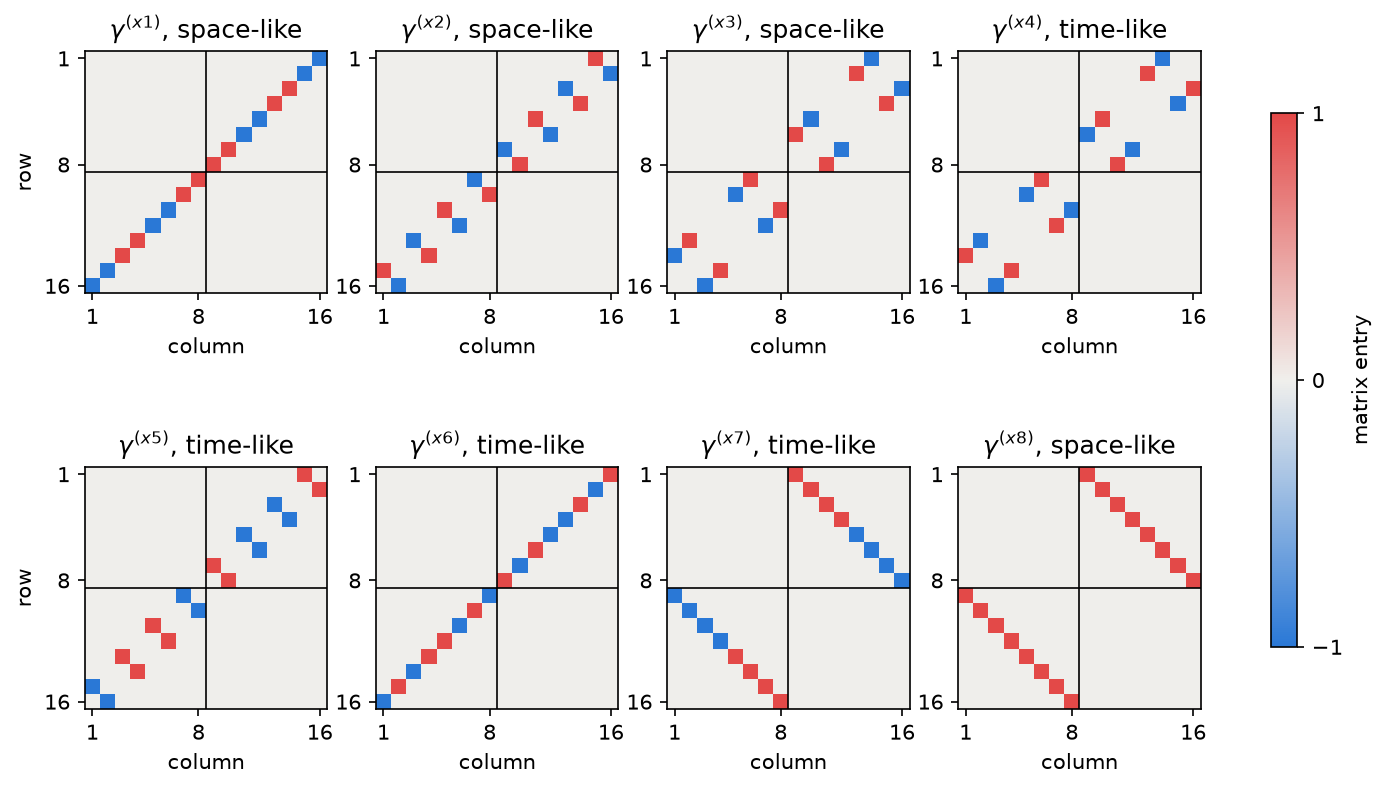

Figure 21a.1 saved as Revision/textbook/figures/21a_1_eight_gammas.png


In [4]:
from matplotlib.colors import LinearSegmentedColormap

# blue for -1, almost white for 0, red for +1
SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])


def heat_map(ax, matrix, title, row_label=True):
    """Draw a 16 x 16 matrix with entries from -1 to +1 (blue -1, pale 0, red +1).
    Rows and columns are numbered from 1; black lines separate the two halves."""
    image = ax.imshow(matrix, cmap=SIGNS, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks([0, 7, 15], ["1", "8", "16"])
    ax.set_yticks([0, 7, 15], ["1", "8", "16"])
    ax.axhline(7.5, color="black", linewidth=0.8)
    ax.axvline(7.5, color="black", linewidth=0.8)
    ax.set_xlabel("column")
    if row_label:
        ax.set_ylabel("row")
    ax.grid(False)
    return image


fig, axes = plt.subplots(2, 4, figsize=(12.0, 6.6))
for k, (ax, x) in enumerate(zip(axes.flat, COORDS)):
    kind = "space-like" if ETA[x] == 1 else "time-like"
    image = heat_map(ax, gamma[x], f"$\\gamma^{{({x})}}$, {kind}",
                     row_label=(k % 4 == 0))
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.7, label="matrix entry")
save_figure(fig, "eight_gammas",
            "The eight real $16 \\times 16$ gamma matrices of the Revision record, "
            "in the author's coordinate order $x1, x2, x3$ (ordinary space), $x4$ "
            "(the time), $x5, x6, x7$ (the deflating extra times), $x8$ (the hidden "
            "direction); horizontal axis the column, vertical axis the row, colour "
            "the entry (red $+1$, blue $-1$, pale $0$). Every matrix has exactly one "
            "nonzero entry in each row and column, and only in the two off-diagonal "
            "$8 \\times 8$ blocks: each gamma exchanges the two halves of the "
            "spinor.")

## 6. C, the chirality Gamma, B and the generators S^ab

The next cell builds, from the gammas, the charge matrix $C = \gamma^{(x8)}
\gamma^{(x1)}\gamma^{(x2)}\gamma^{(x3)}$, the chirality $\Gamma = \gamma^{(x8)}
\gamma^{(x1)}\cdots\gamma^{(x7)}$, the Krein matrix $B = -iC\gamma^{(x4)}$ (`1j` is
Python's imaginary unit $i$) and the 28 generators $S^{ab} = \tfrac14[\gamma^a,
\gamma^b]$ of the rotations and boosts. It compares $C$ and $\Gamma$ with the
matrices stored in the record and checks: $C$ is real and symmetric with $C^2 =
1$; $\Gamma = \mathrm{diag}(-1, \dots, -1, +1, \dots, +1)$ (eight of each); all
$S^{ab}$ are real (record check representation_real); $B$ is purely imaginary,
Hermitian and $B^2 = 1$ (record check B_imaginary_hermitian).

In [5]:
C = product(["x8", "x1", "x2", "x3"])  # the charge matrix (the author's sigma16)
Gamma = product(["x8", "x1", "x2", "x3", "x4", "x5", "x6", "x7"])  # the chirality
B = -1j * (C @ gamma["x4"])  # B = -i C gamma^(x4), a complex matrix
pairs = [(a, b) for i, a in enumerate(COORDS) for b in COORDS[i + 1:]]  # 28 pairs
S_gen = {(a, b): (gamma[a] @ gamma[b] - gamma[b] @ gamma[a]) / 4 for a, b in pairs}

same_as_record = (np.array_equal(C, np.array(fixture["C"]))
                  and np.array_equal(Gamma, np.array(fixture["Gamma"])))
gamma_diag = np.diag(np.concatenate([-np.ones(8), np.ones(8)])).astype(np.int64)
check(same_as_record and np.array_equal(Gamma, gamma_diag),
      "C and Gamma equal the record; Gamma = diag(-1 (8 times), +1 (8 times))")
check(np.array_equal(C.T, C) and np.array_equal(C @ C, I16)
      and all(np.isrealobj(s) for s in S_gen.values()) and lead_passed(
          "representation_real"),
      "gamma^a, C (symmetric, C^2 = 1) and all 28 S^ab are real",
      record=f"{RECORD}, check representation_real")
check(np.array_equal(B.real, np.zeros((16, 16))) and np.allclose(B, B.conj().T)
      and np.allclose(B @ B, np.eye(16)) and lead_passed("B_imaginary_hermitian"),
      "B = -i C gamma^(x4) is purely imaginary, Hermitian, B^2 = 1",
      record=f"{RECORD}, check B_imaginary_hermitian")

PASS C and Gamma equal the record; Gamma = diag(-1 (8 times), +1 (8 times))
PASS gamma^a, C (symmetric, C^2 = 1) and all 28 S^ab are real
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    representation_real
PASS B = -i C gamma^(x4) is purely imaginary, Hermitian, B^2 = 1
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    B_imaginary_hermitian


## 7. Every conjugation matrix, solved exactly

Write the unknown matrix $M$ as its 256 entries $M_{rc}$. For one gamma the
condition $M(\gamma^a)^* - s\,\gamma^a M = 0$ is a $16 \times 16$ matrix of
zeros, that is, 256 linear equations in the 256 unknowns; for all eight gammas
2048 equations. (For both signs together: 4096.) Reading the entries of $M$ row
by row as one long column $y$, the product $MG$ becomes $(1 \otimes G^T)\,y$ and
$GM$ becomes $(G \otimes 1)\,y$, where $\otimes$ is the Kronecker product
(`np.kron`): the block matrix whose block $(r, c)$ is the entry $A_{rc}$ times the
whole matrix $B$. The next cell builds the coefficient matrix of these equations
and solves them **exactly**, with rational numbers (sympy's `DomainMatrix` over
the rationals `QQ`), so no rounding can hide or invent a solution.

In [6]:
import sympy as sp  # exact algebra
from sympy.polys.matrices import DomainMatrix  # exact matrices over the rationals


def conjugation_system(s, directions=COORDS):
    """Coefficient matrix of M conj(gamma^a) - s gamma^a M = 0 for the 256
    unknowns M_rc (read row by row), one block of 256 equations per direction."""
    blocks = []
    for x in directions:
        G_conj = np.conj(gamma[x]).astype(np.int64)  # (gamma^a)*, equal to gamma^a
        blocks.append(np.kron(I16, G_conj.T) - s * np.kron(gamma[x], I16))
    return np.vstack(blocks)


def exact_solutions(A):
    """A basis of all solutions y of A y = 0, each returned as a 16 x 16 matrix."""
    null = DomainMatrix.from_list(A.tolist(), sp.QQ).nullspace().to_Matrix()
    return [np.array(null.row(k).tolist()[0], dtype=object).reshape(16, 16)
            for k in range(null.rows)]


def proportional(X, Y):
    """True when X and Y are nonzero and X is a number times Y."""
    X = np.array(X, dtype=float).reshape(-1)
    Y = np.array(Y, dtype=float).reshape(-1)
    return bool(X.any() and Y.any() and np.linalg.matrix_rank(np.array([X, Y])) == 1)


A_same, A_reversed = conjugation_system(+1), conjugation_system(-1)
M_same, M_reversed = exact_solutions(A_same), exact_solutions(A_reversed)
say(f"s = +1: {A_same.shape[0]} equations, {len(M_same)} independent solution(s)")
say(f"s = -1: {A_reversed.shape[0]} equations, {len(M_reversed)} independent "
    "solution(s)")
check(len(M_same) == 1 and proportional(M_same[0], I16)
      and lead_passed("intertwiners_same_mass"),
      "s = +1 (same mass): the solutions are the multiples of the identity",
      record=f"{RECORD}, check intertwiners_same_mass")
check(len(M_reversed) == 1 and proportional(M_reversed[0], Gamma)
      and lead_passed("intertwiners_reversed_mass"),
      "s = -1 (mass reversed): the solutions are the multiples of Gamma",
      record=f"{RECORD}, check intertwiners_reversed_mass")

s = +1: 2048 equations, 1 independent solution(s)
s = -1: 2048 equations, 1 independent solution(s)
PASS s = +1 (same mass): the solutions are the multiples of the identity
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    intertwiners_same_mass
PASS s = -1 (mass reversed): the solutions are the multiples of Gamma
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    intertwiners_reversed_mass


**Each equation halves the solution space.** Imposing the condition for only the
first $k$ gammas ($k = 0, 1, \dots, 8$) leaves more solutions. The next cell
computes the dimension of the solution space for each $k$ exactly, as $256$ minus
the *rank* of the coefficient matrix (the number of independent equations among
them), and plots it. Why halving: a matrix $M$ that commutes with $\gamma^{(x1)}$
maps each of its two eigenspaces (dimension 8 each, eigenvalues $\pm1$) into
itself, which leaves $8 \cdot 8 + 8 \cdot 8 = 128$ free entries of the 256; each
further gamma cuts the freedom in half again, down to $256/2^8 = 1$.

s = +1: dimensions for k = 0..8: [256, 128, 64, 32, 16, 8, 4, 2, 1]
s = -1: dimensions for k = 0..8: [256, 128, 64, 32, 16, 8, 4, 2, 1]
PASS each gamma equation halves the solution space: 256, 128, ..., 2, 1


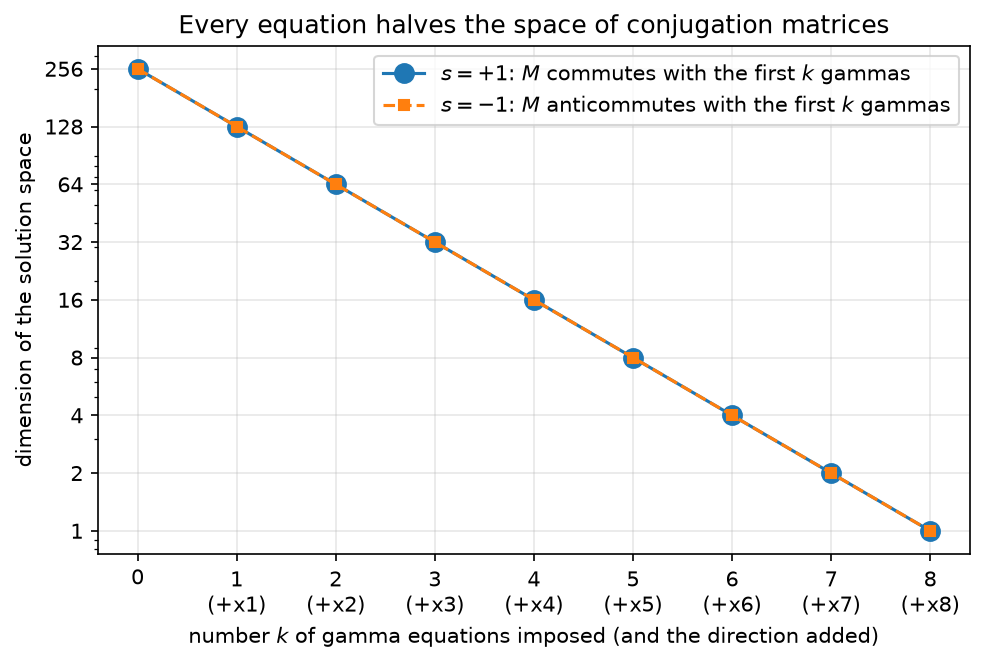

Figure 21a.2 saved as Revision/textbook/figures/21a_2_halving_solutions.png


In [7]:
dimensions = {}
for s in (+1, -1):
    dims = [256]  # k = 0: no equation, every matrix is a solution
    for k in range(1, 9):
        A = conjugation_system(s, COORDS[:k])  # the first k directions only
        rank = DomainMatrix.from_list(A.tolist(), sp.ZZ).rank()  # exact rank
        dims.append(256 - rank)
    dimensions[s] = dims
    say(f"s = {s:+d}: dimensions for k = 0..8: {dims}")
check(dimensions[+1] == dimensions[-1] == [256 // 2 ** k for k in range(9)],
      "each gamma equation halves the solution space: 256, 128, ..., 2, 1")

fig, ax = plt.subplots(figsize=(7.5, 4.4))
k_values = np.arange(9)
ax.semilogy(k_values, dimensions[+1], "o-", markersize=9,
            label="$s = +1$: $M$ commutes with the first $k$ gammas")
ax.semilogy(k_values, dimensions[-1], "s--", markersize=5,
            label="$s = -1$: $M$ anticommutes with the first $k$ gammas")
ax.set_xticks(k_values, ["0"] + [f"{k}\n(+{x})" for k, x in zip(range(1, 9), COORDS)])
ax.set_yticks([1, 2, 4, 8, 16, 32, 64, 128, 256],
              ["1", "2", "4", "8", "16", "32", "64", "128", "256"])
ax.set_xlabel("number $k$ of gamma equations imposed (and the direction added)")
ax.set_ylabel("dimension of the solution space")
ax.set_title("Every equation halves the space of conjugation matrices")
ax.legend()
save_figure(fig, "halving_solutions",
            "The dimension of the space of $16 \\times 16$ matrices $M$ that obey "
            "$M(\\gamma^a)^\\ast = s\\,\\gamma^a M$ for the first $k$ directions only "
            "(computed exactly as $256$ minus the rank of the equations), for "
            "$s = +1$ (circles) and $s = -1$ (squares); horizontal axis $k$ with "
            "the direction added, vertical axis the dimension on a logarithmic "
            "scale. Both sequences are $256/2^k$: every new gamma halves the "
            "freedom, and with all eight only one direction is left, the multiples "
            "of $1$ ($s = +1$) or of $\\Gamma$ ($s = -1$).")

## 8. The two charge-conjugation matrices

From $M = 1$ and $M = \Gamma$ we get $\mathcal{C} = MC$:
$$\mathcal{C}_+ = C, \qquad \mathcal{C}_- = \Gamma C .$$
The next cell checks the **transposition rules** that characterise them,
$\mathcal{C}_+^{-1}\gamma^a\mathcal{C}_+ = -(\gamma^a)^T$ and
$\mathcal{C}_-^{-1}\gamma^a\mathcal{C}_- = +(\gamma^a)^T$ for every $a$, and that
both are real (and symmetric). Then it solves, again exactly, the equations
$\gamma^a X = \zeta X(\gamma^a)^T$ for all $a$ with $\zeta = -1$ and $\zeta = +1$:
their only solutions are the multiples of $C$ and of $\Gamma C$, so these two
matrices are the only ones with such transposition rules.

In [8]:
calC_plus = C  # M = 1
calC_minus = Gamma @ C  # M = Gamma
inv_plus = np.linalg.inv(calC_plus)  # the inverse matrix
inv_minus = np.linalg.inv(calC_minus)
check(all(np.allclose(inv_plus @ gamma[x] @ calC_plus, -gamma[x].T) for x in COORDS)
      and np.array_equal(calC_plus.T, calC_plus)
      and lead_passed("charge_conjugation_matrix_plus"),
      "calC_+ = C: calC_+^-1 gamma^a calC_+ = -(gamma^a)^T, real, symmetric",
      record=f"{RECORD}, check charge_conjugation_matrix_plus")
check(all(np.allclose(inv_minus @ gamma[x] @ calC_minus, gamma[x].T) for x in COORDS)
      and np.array_equal(calC_minus.T, calC_minus)
      and lead_passed("charge_conjugation_matrix_minus"),
      "calC_- = Gamma C: calC_-^-1 gamma^a calC_- = +(gamma^a)^T, real, symmetric",
      record=f"{RECORD}, check charge_conjugation_matrix_minus")


def transposition_system(zeta):
    """Coefficient matrix of gamma^a X - zeta X (gamma^a)^T = 0 for all a."""
    return np.vstack([np.kron(gamma[x], I16) - zeta * np.kron(I16, gamma[x])
                      for x in COORDS])


X_minus = exact_solutions(transposition_system(-1))  # expected: multiples of C
X_plus = exact_solutions(transposition_system(+1))  # expected: multiples of Gamma C
check(len(X_minus) == 1 and proportional(X_minus[0], calC_plus)
      and len(X_plus) == 1 and proportional(X_plus[0], calC_minus),
      "gamma^a X = zeta X (gamma^a)^T: zeta = -1 only C, zeta = +1 only Gamma C")

PASS calC_+ = C: calC_+^-1 gamma^a calC_+ = -(gamma^a)^T, real, symmetric
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    charge_conjugation_matrix_plus
PASS calC_- = Gamma C: calC_-^-1 gamma^a calC_- = +(gamma^a)^T, real, symmetric
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    charge_conjugation_matrix_minus
PASS gamma^a X = zeta X (gamma^a)^T: zeta = -1 only C, zeta = +1 only Gamma C


The next cell draws the two charge-conjugation matrices and the chirality that
relates them. Since $\Gamma$ is $-1$ on the first eight components and $+1$ on
the last eight, $\Gamma C$ is $C$ with the signs of its first eight rows reversed.

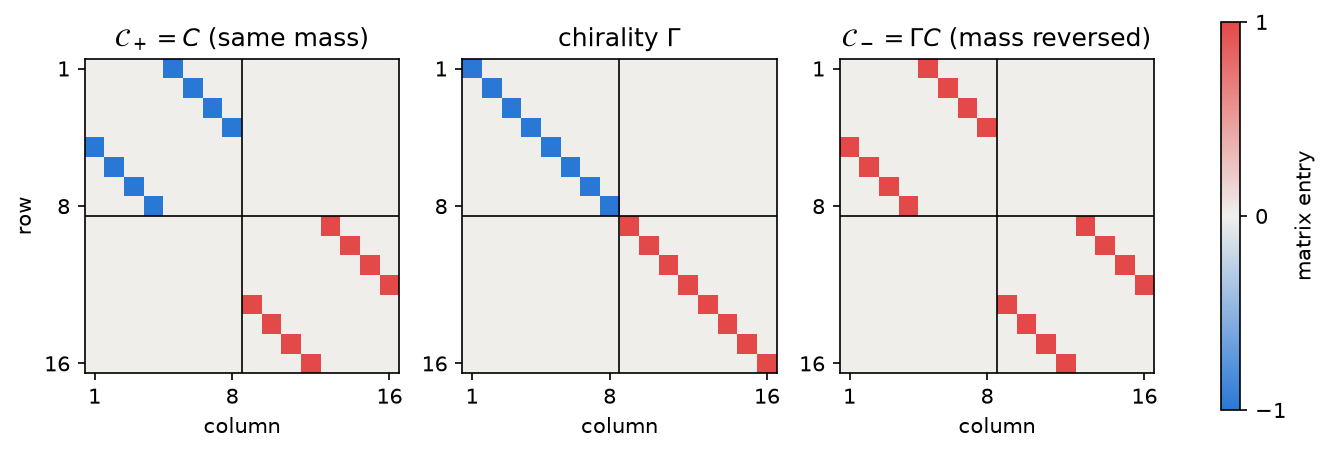

Figure 21a.3 saved as Revision/textbook/figures/21a_3_conjugation_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2))
heat_map(axes[0], calC_plus, r"$\mathcal{C}_+ = C$ (same mass)")
heat_map(axes[1], Gamma, r"chirality $\Gamma$", row_label=False)
image = heat_map(axes[2], calC_minus, r"$\mathcal{C}_- = \Gamma C$ (mass reversed)",
                 row_label=False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "conjugation_matrices",
            "Heat maps of the two charge-conjugation matrices and of the chirality "
            "that relates them: $\\mathcal{C}_+ = C$ (left, the conjugation that "
            "keeps the mass), $\\Gamma$ (middle) and $\\mathcal{C}_- = \\Gamma C$ "
            "(right, the conjugation that reverses the mass); horizontal axis the "
            "column, vertical axis the row, colour the entry (red $+1$, blue $-1$, "
            "pale $0$). $C$ and $\\Gamma C$ have their entries only in the two "
            "diagonal blocks, and they differ only by the sign of the upper half, "
            "where $\\Gamma = -1$.")

## 9. The two reality (Majorana) conditions

A field that equals its own conjugate, $\Psi^c = \Psi$, satisfies
$\Psi = M\Psi^*$. Applying the condition twice gives $\Psi = M(M\Psi^*)^* =
MM^*\Psi$, so the condition can hold for nonzero fields without contradiction only
if $MM^* = 1$. For $M = 1$ the condition is $\Psi = \Psi^*$: the field is real.
For $M = \Gamma$ it is $\Psi = \Gamma\Psi^*$: the last eight components (where
$\Gamma = +1$) are real and the first eight (where $\Gamma = -1$) are purely
imaginary. The next cell checks $MM^* = 1$ for both (record check
majorana_conditions_consistent), makes one example of each kind from a fixed
complex column $v$ by $\Psi = (v + Mv^*)/2$, checks that each example satisfies
its condition, and draws them.

PASS M M* = 1 for M = 1 and M = Gamma: both reality conditions are consistent
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    majorana_conditions_consistent
PASS the two example fields satisfy Psi = Psi* and Psi = Gamma Psi*


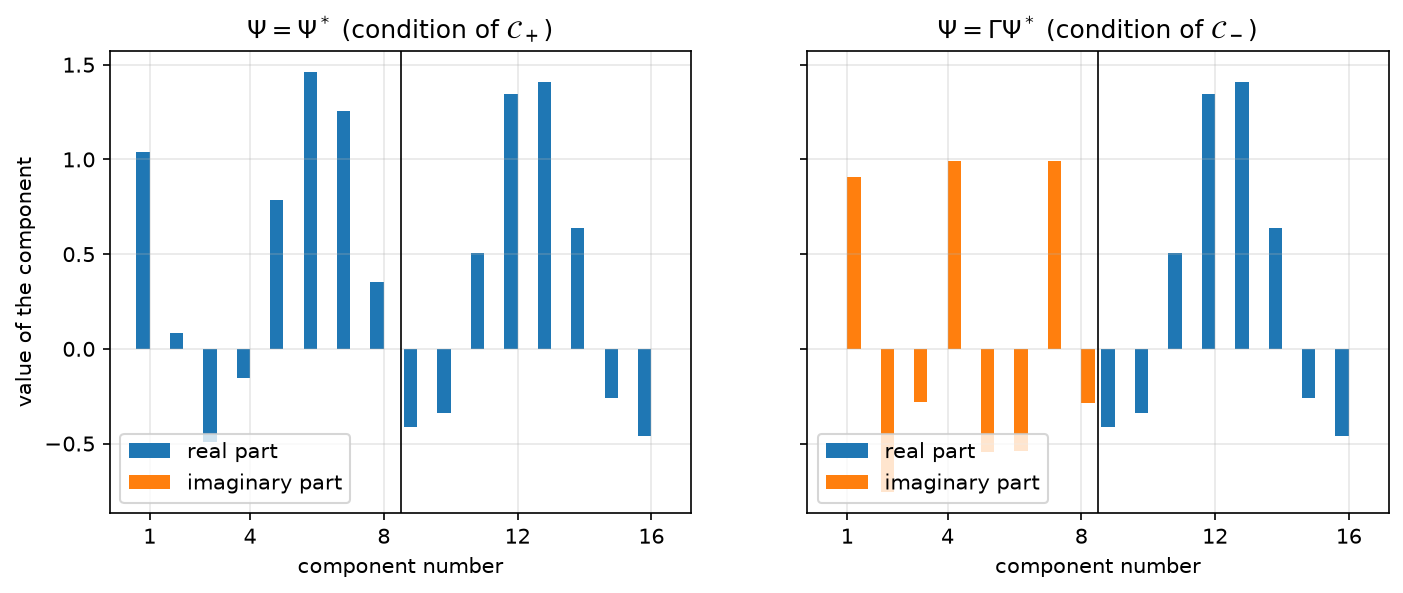

Figure 21a.4 saved as Revision/textbook/figures/21a_4_reality_conditions.png


In [10]:
check(np.array_equal(I16 @ np.conj(I16), I16)
      and np.array_equal(Gamma @ np.conj(Gamma), I16)
      and lead_passed("majorana_conditions_consistent"),
      "M M* = 1 for M = 1 and M = Gamma: both reality conditions are consistent",
      record=f"{RECORD}, check majorana_conditions_consistent")

rows = np.arange(1, 17)  # the component numbers 1, ..., 16
v = (np.cos(rows) + 0.5) + 1j * np.sin(2.0 * rows)  # a fixed complex column
psi_real = (v + np.conj(v)) / 2  # satisfies Psi = Psi*
psi_gamma = (v + Gamma @ np.conj(v)) / 2  # satisfies Psi = Gamma Psi*
check(np.allclose(psi_real, np.conj(psi_real))
      and np.allclose(psi_gamma, Gamma @ np.conj(psi_gamma)),
      "the two example fields satisfy Psi = Psi* and Psi = Gamma Psi*")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), sharey=True)
for ax, psi, title in ((axes[0], psi_real, r"$\Psi = \Psi^*$ (condition of "
                        r"$\mathcal{C}_+$)"),
                       (axes[1], psi_gamma, r"$\Psi = \Gamma\Psi^*$ (condition of "
                        r"$\mathcal{C}_-$)")):
    ax.bar(rows - 0.2, psi.real, width=0.4, label="real part")
    ax.bar(rows + 0.2, psi.imag, width=0.4, label="imaginary part")
    ax.axvline(8.5, color="black", linewidth=0.8)
    ax.set_xticks([1, 4, 8, 12, 16])
    ax.set_xlabel("component number")
    ax.set_title(title)
    ax.legend(loc="lower left")
axes[0].set_ylabel("value of the component")
save_figure(fig, "reality_conditions",
            "One field satisfying each reality (Majorana) condition, made from the "
            "same complex column: left $\\Psi = \\Psi^\\ast$ (every imaginary part is "
            "zero), right $\\Psi = \\Gamma\\Psi^\\ast$ (components 1 to 8, where "
            "$\\Gamma = -1$, are purely imaginary; components 9 to 16, where "
            "$\\Gamma = +1$, are real); horizontal axis the component number, "
            "vertical axis the real part (left bar of each pair) and the imaginary "
            "part (right bar). Both conditions can be imposed, because "
            "$MM^\\ast = 1$ for $M = 1$ and for $M = \\Gamma$.")

## 10. The conjugations acting on an exact solution in the author's metric

The Revision field-theory record (`Revision/theory/field-theory.json`, formula
exact_solutions, item (i)) gives an exact solution of the field equation with
$U = 0$ in the author's curved metric:
$$\Psi = \sin^\alpha z\,\Big(\cosh(kx_4)\,1 + \frac{\sinh(kx_4)}{k}\,M_m\Big)\chi,
\quad M_m = -m\gamma^{(x4)} + b\,\gamma^{(x4)}\gamma^{(x8)},\quad b = 3H(2\alpha+1),
\quad k^2 = b^2 - m^2,$$
with $z = 6Hx_8$ and a constant column $\chi$. It depends only on $x_4$ and $x_8$.
The field equation of the record reads
$$e^{-a_4}\sin^{-1/6}z\,(\gamma^{(x1)}\partial_1 + \gamma^{(x2)}\partial_2 +
\gamma^{(x3)}\partial_3)\Psi + \gamma^{(x4)}\partial_4\Psi + e^{a_4}\sin^{-1/6}z
\,(\gamma^{(x5)}\partial_5 + \gamma^{(x6)}\partial_6 + \gamma^{(x7)}\partial_7)\Psi
+ \tan z\,\gamma^{(x8)}\partial_8\Psi + 3H\gamma^{(x8)}\Psi = m\Psi .$$
The derivatives along $x1, x2, x3, x5, x6, x7$ vanish for this $\Psi$, so the
factors $e^{\mp a_4}$ drop out: the solution holds for **every** history
$a_4(x_4)$, in particular for the one in which the three extra times deflate
exponentially. What remains is
$$E_m[\Psi] = \gamma^{(x4)}\partial_4\Psi + 6H\tan z\,\gamma^{(x8)}\partial_z\Psi
+ 3H\gamma^{(x8)}\Psi - m\Psi = 0 ,$$
where $\partial_8 = 6H\,\partial_z$ by the chain rule ($z = 6Hx_8$).

We take $H = 1/6$ (so that $z = x_8$), $\alpha = 1$ and $m = 2$. Then $b = 3/2$
and $k^2 = 9/4 - 4 = -7/4 < 0$, so $k = i\sqrt7/2$ is imaginary; with
$\cosh(i\theta) = \cos\theta$ and $\sinh(i\theta)/i = \sin\theta$ the solution
oscillates: $\cosh(kx_4) = \cos(wx_4)$ and $\sinh(kx_4)/k = \sin(wx_4)/w$ with
$w = \sqrt7/2$. Both are real functions, so conjugation acts only on $\chi$. The
next cell builds $\Psi$ with sympy for a fixed complex $\chi$ and checks, exactly,
that $E_m[\Psi] = 0$ (Revision check exact_solution_family_x4_x8).

In [11]:
x4, z = sp.symbols("x4 z", real=True)  # the time x4 and the angle z = 6 H x8
H, alpha, m = sp.Rational(1, 6), 1, 2  # the parameters chosen above
b = 3 * H * (2 * alpha + 1)  # b = 3/2
w = sp.sqrt(m ** 2 - b ** 2)  # k = i w with w = sqrt(7)/2
G = {x: sp.Matrix(gamma[x].tolist()) for x in COORDS}  # exact sympy matrices
Gamma_s = sp.Matrix(Gamma.tolist())


def M_of(mass):
    """M_m = -m gamma^(x4) + b gamma^(x4) gamma^(x8)."""
    return -mass * G["x4"] + b * G["x4"] * G["x8"]


def E(mass, field):
    """E_m[Psi] = gamma^(x4) d4 Psi + 6H tan z gamma^(x8) dz Psi + 3H gamma^(x8) Psi
    - m Psi (the field equation of the record for fields of x4 and z only)."""
    tan_z = sp.sin(z) / sp.cos(z)  # tan z written as sin z / cos z
    return (G["x4"] * field.diff(x4) + 6 * H * tan_z * G["x8"] * field.diff(z)
            + 3 * H * G["x8"] * field - mass * field)


# a fixed complex column chi with exact entries (j + i (17 - j)) / 16, j = 1..16
chi = sp.Matrix([sp.Rational(j, 16) + sp.I * sp.Rational(17 - j, 16)
                 for j in range(1, 17)])
U = sp.cos(w * x4) * sp.eye(16) + sp.sin(w * x4) / w * M_of(m)  # real 16 x 16
Psi = sp.sin(z) ** alpha * U * chi
check(E(m, Psi).expand() == sp.zeros(16, 1)
      and sp.simplify(M_of(m) ** 2 + w ** 2 * sp.eye(16)) == sp.zeros(16, 16),
      "the record's exact solution solves the field equation (mass m = 2)",
      record="Revision/theory/reports/python-field-theory.json, check "
      "exact_solution_family_x4_x8")

PASS the record's exact solution solves the field equation (mass m = 2)
     reproduces Revision/theory/reports/python-field-theory.json, check
    exact_solution_family_x4_x8


The next cell forms the two conjugates. Because the matrix $U$ in $\Psi =
\sin z\,U\chi$ is real, $\Psi^* = \sin z\,U\chi^*$ and $\Gamma\Psi^* = \sin z\,
\Gamma U\chi^*$. The general argument of section 4 predicts: $\Psi^*$ solves the
equation with the **same** mass $m = 2$, and $\Gamma\Psi^*$ with the **reversed**
mass $-2$. The cell checks both exactly, and checks the two negative controls:
$\Psi^*$ does not solve the equation with $-2$, and $\Gamma\Psi^*$ does not solve
it with $+2$.

In [12]:
Psi_conj = Psi.conjugate()  # Psi*: every entry complex-conjugated (x4, z are real)
Psi_gamma_conj = Gamma_s * Psi_conj  # Gamma Psi*


def vanishes(vector):
    """True when every component expands to exactly zero (sympy multiplies out
    every product; cos z / cos z cancels automatically)."""
    return vector.expand() == sp.zeros(16, 1)


check(vanishes(E(m, Psi_conj)) and vanishes(E(-m, Psi_gamma_conj)),
      "Psi* solves the equation with mass +2, Gamma Psi* with mass -2 (exact)")
check(not vanishes(E(-m, Psi_conj)) and not vanishes(E(m, Psi_gamma_conj)),
      "negative controls: Psi* fails with -2, Gamma Psi* fails with +2")

PASS Psi* solves the equation with mass +2, Gamma Psi* with mass -2 (exact)
PASS negative controls: Psi* fails with -2, Gamma Psi* fails with +2


The next cell turns the exact expressions into fast numerical functions
(`sp.lambdify`) and evaluates them along the time $x_4$ at the fixed angle
$z = \pi/4$. It computes the charge density $J^{(x4)} = \Psi^\dagger B\Psi$ of
$\Psi$, $\Psi^*$ and $\Gamma\Psi^*$ (`np.einsum("tr,rc,tc->t", ...)` forms
$\sum_{r,c}\Psi_r^* B_{rc}\Psi_c$ at every time $t$) and checks the signs of the
table of section 11 below: $\Psi^*$ carries $-J^{(x4)}$, $\Gamma\Psi^*$ carries
$+J^{(x4)}$. It also computes the size of the left-hand side of the field
equation, $|E_{\pm2}[\cdot]|$ (the square root of the sum of the squared moduli of
its 16 components). Where a field solves the equation, $|E|$ is zero up to
rounding (about $10^{-15}$); where it does not, $|E|$ is of order 1. The figure
shows the charge densities on the left and $|E|$ on a logarithmic scale on the
right.

largest |E| of the two solutions: 7.8e-16
smallest |E| of the two controls: 9.67
PASS numerically: the solutions give |E| below 1e-12, the controls above 0.1
PASS charge density: Psi* has -J^(x4), Gamma Psi* has +J^(x4) at every time


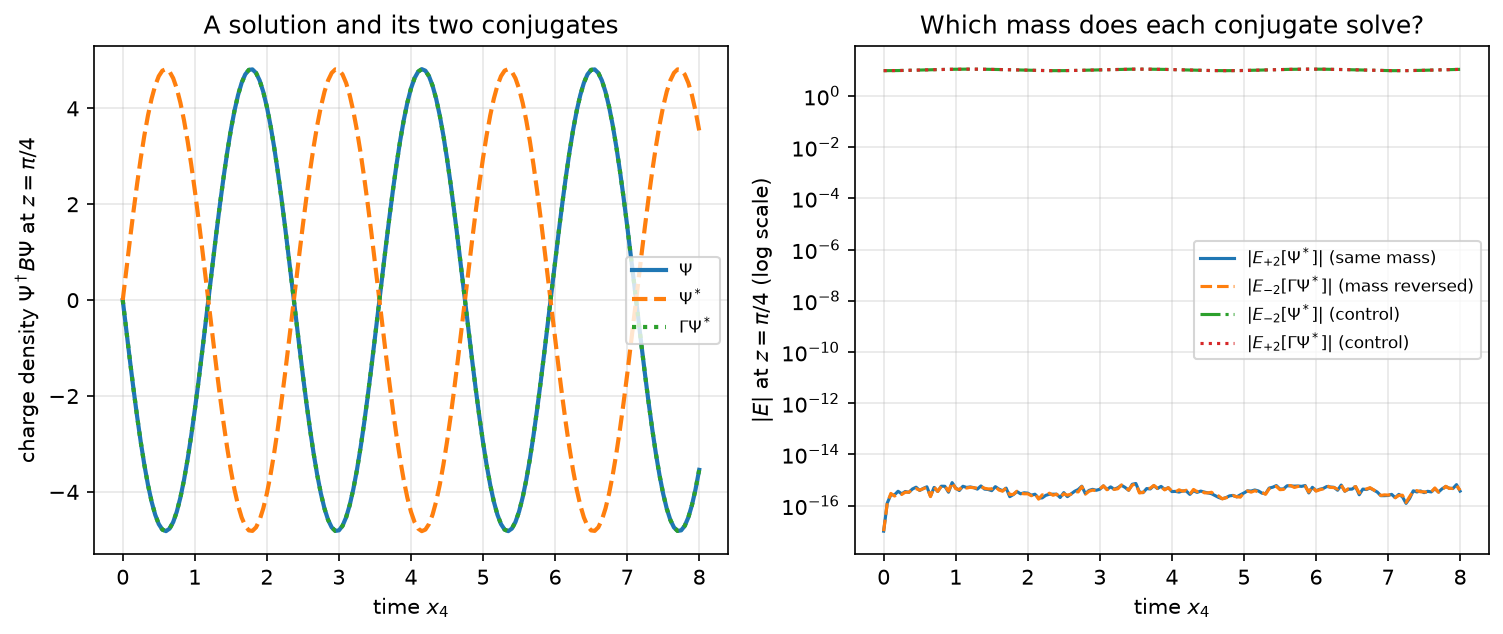

Figure 21a.5 saved as Revision/textbook/figures/21a_5_curved_solution_images.png


In [13]:
times = np.linspace(0.0, 8.0, 161)  # 161 times x4 from 0 to 8
z_fixed = np.pi / 4


def numeric(expression):
    """Evaluate a sympy 16 x 1 expression of x4 at z = pi/4 for all times."""
    f = sp.lambdify((x4, z), expression, "numpy")
    return np.array([np.array(f(t, z_fixed), dtype=complex).reshape(16)
                     for t in times])


def size(expression):
    """|E| at every time: the length of the 16-component column."""
    return np.linalg.norm(numeric(expression), axis=1)


curves = {
    r"$|E_{+2}[\Psi^*]|$ (same mass)": size(E(m, Psi_conj)),
    r"$|E_{-2}[\Gamma\Psi^*]|$ (mass reversed)": size(E(-m, Psi_gamma_conj)),
    r"$|E_{-2}[\Psi^*]|$ (control)": size(E(-m, Psi_conj)),
    r"$|E_{+2}[\Gamma\Psi^*]|$ (control)": size(E(m, Psi_gamma_conj)),
}
floor = 1e-17  # added before taking the logarithm, so that 0 can be drawn
values = list(curves.values())
say(f"largest |E| of the two solutions: {max(values[0].max(), values[1].max()):.1e}")
say(f"smallest |E| of the two controls: {min(values[2].min(), values[3].min()):.2f}")
check(max(values[0].max(), values[1].max()) < 1e-12
      and min(values[2].min(), values[3].min()) > 0.1,
      "numerically: the solutions give |E| below 1e-12, the controls above 0.1")

B_c = B.astype(complex)  # the charge density is J^(x4) = Psi^dagger B Psi
density = {}
for field, label in ((Psi, r"$\Psi$"), (Psi_conj, r"$\Psi^*$"),
                     (Psi_gamma_conj, r"$\Gamma\Psi^*$")):
    values_f = numeric(field)  # shape (161, 16): the field at every time
    density[label] = np.einsum("tr,rc,tc->t", np.conj(values_f), B_c, values_f).real
d_psi, d_conj, d_gconj = density.values()
check(np.allclose(d_conj, -d_psi) and np.allclose(d_gconj, d_psi)
      and np.ptp(d_psi) > 0.1,
      "charge density: Psi* has -J^(x4), Gamma Psi* has +J^(x4) at every time")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
for (label, values_d), style in zip(density.items(), ["-", "--", ":"]):
    axes[0].plot(times, values_d, style, linewidth=2, label=f"{label}")
axes[0].set_xlabel("time $x_4$")
axes[0].set_ylabel("charge density $\\Psi^\\dagger B\\Psi$ at $z = \\pi/4$")
axes[0].set_title("A solution and its two conjugates")
axes[0].legend(fontsize=8)
for (label, values_e), style in zip(curves.items(), ["-", "--", "-.", ":"]):
    axes[1].semilogy(times, values_e + floor, style, label=label)
axes[1].set_xlabel("time $x_4$")
axes[1].set_ylabel("$|E|$ at $z = \\pi/4$ (log scale)")
axes[1].set_title("Which mass does each conjugate solve?")
axes[1].legend(fontsize=8)
save_figure(fig, "curved_solution_images",
            "Charge conjugation acting on an exact solution of the field equation "
            "in the author's metric ($H = 1/6$, $\\alpha = 1$, mass $m = 2$, valid "
            "for every history $a_4$). Left: the charge density "
            "$\\Psi^\\dagger B\\Psi$ of $\\Psi$ (solid), $\\Psi^\\ast$ (dashed) and "
            "$\\Gamma\\Psi^\\ast$ (dotted, on top of the solid curve) versus the "
            "time $x_4$ at $z = \\pi/4$ (pure numbers); $\\Psi^\\ast$ carries the "
            "opposite charge density. Right: the size $|E|$ of the left-hand "
            "side of the field equation versus $x_4$, logarithmic scale. $\\Psi^\\ast$ "
            "solves the equation with the same mass $+2$ and $\\Gamma\\Psi^\\ast$ the "
            "one with the reversed mass $-2$ ($|E|$ at rounding level, about "
            "$10^{-16}$), while the exchanged masses fail ($|E|$ of order 1).")

## 11. How the bilinears change: the sign table

Under $\Psi \to M\Psi^*$ a bilinear $\Psi^\dagger K\Psi = \sum_{r,c}\Psi_r^*K_{rc}
\Psi_c$ becomes $\sum_{r,c}(M\Psi^*)_r^*K_{rc}(M\Psi^*)_c = \sum\Psi_r(M^\dagger
KM)_{rc}\Psi_c^*$ ($M$ is real). To bring this back to the form $\sum\Psi^*_c
(\dots)\Psi_r$ we exchange the two factors $\Psi_r$ and $\Psi_c^*$: for commuting
components this costs nothing, for anticommuting components a sign. Hence the new
bilinear is $\Psi^\dagger K'\Psi$ with
$$K' = \epsilon\,(M^\dagger KM)^T ,\qquad \epsilon = +1 \text{ (commuting)},\
\epsilon = -1 \text{ (anticommuting)} .$$
If $K' = \pm K$, the bilinear keeps or reverses its sign. The next cell computes
this for the scalar $S$ ($K = C$) and the eight currents $J^a$ ($K = -iC\gamma^a$),
for both matrices and both kinds of components, and compares with the signs
measured in the Revision record (check bilinears_under_charge_conjugation).

In [14]:
def effective(Mmat, K, eps):
    """The matrix K' of the bilinear after Psi -> M Psi*, with the reorder sign eps."""
    return eps * (Mmat.conj().T @ K @ Mmat).T


def sign_of(Kp, K):
    """+1 if K' = K, -1 if K' = -K, 0 otherwise."""
    return 1 if np.allclose(Kp, K) else (-1 if np.allclose(Kp, -K) else 0)


K_S = C.astype(complex)  # the scalar S = Psi^dagger C Psi
K_J = [-1j * (C @ gamma[x]) for x in COORDS]  # the currents J^a
measured = {}
for label, Mmat in (("plus", I16), ("minus", Gamma)):
    for eps in (1, -1):
        sS = sign_of(effective(Mmat, K_S, eps), K_S)
        sJ = [sign_of(effective(Mmat, K, eps), K) for K in K_J]
        measured[f"{label},eps={eps}"] = [sS, sJ]
        kind = "commuting" if eps == 1 else "anticommuting"
        say(f"calC_{'+' if label == 'plus' else '-'}, {kind:13}: S -> {sS:+d} S, "
            f"J -> {sJ[0]:+d} J (all eight components alike: {len(set(sJ)) == 1})")
detail = LEAD["bilinears_under_charge_conjugation"]["detail"]
recorded = json.loads(detail.split("measured: ", 1)[1])  # the record's own table
check(measured == recorded and lead_passed("bilinears_under_charge_conjugation"),
      "signs of S and J under calC_+ and calC_-, both statistics, equal the record",
      record=f"{RECORD}, check bilinears_under_charge_conjugation")

calC_+, commuting    : S -> +1 S, J -> -1 J (all eight components alike: True)
calC_+, anticommuting: S -> -1 S, J -> +1 J (all eight components alike: True)
calC_-, commuting    : S -> +1 S, J -> +1 J (all eight components alike: True)
calC_-, anticommuting: S -> -1 S, J -> -1 J (all eight components alike: True)
PASS signs of S and J under calC_+ and calC_-, both statistics, equal the record
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    bilinears_under_charge_conjugation


**All 256 bilinears.** Every $16 \times 16$ matrix is a combination of the 256
products $\Gamma_A = \gamma^{a_1}\gamma^{a_2}\cdots\gamma^{a_k}$ ($a_1 < \dots <
a_k$ in the order $x1, \dots, x8$, $k = 0, \dots, 8$; $\Gamma_\emptyset = 1$), so
the bilinears $\bar\Psi\Gamma_A\Psi = \Psi^\dagger C\Gamma_A\Psi$ are a complete
list. The next cell computes the sign of each of them for the four cases. The
result depends only on the number $k$ of gammas (the *degree*): for commuting
components $\mathcal{C}_+$ gives $(-1)^{k(k+1)/2}$ and $\mathcal{C}_-$ gives
$(-1)^{k(k-1)/2}$; anticommuting components add one more factor $-1$.

In [15]:
CASES = [("plus", I16, 1), ("plus", I16, -1), ("minus", Gamma, 1), ("minus", Gamma, -1)]
degree_signs = np.zeros((4, 9), dtype=int)  # rows: the four cases, columns: k
for row, (label, Mmat, eps) in enumerate(CASES):
    for k in range(9):
        signs = {sign_of(effective(Mmat, C @ product(A), eps), C @ product(A))
                 for A in itertools.combinations(COORDS, k)}
        # one common sign for all products of degree k, else 0
        degree_signs[row, k] = signs.pop() if len(signs) == 1 else 0
k_all = np.arange(9)
formula = np.array([(-1) ** (k_all * (k_all + 1) // 2),
                    -(-1) ** (k_all * (k_all + 1) // 2),
                    (-1) ** (k_all * (k_all - 1) // 2),
                    -(-1) ** (k_all * (k_all - 1) // 2)])
for row, (label, _, eps) in enumerate(CASES):
    say(f"calC_{'+' if label == 'plus' else '-'}, eps = {eps:+d}: signs for k = 0..8: "
        + " ".join(f"{s:+d}" for s in degree_signs[row]))
check(np.array_equal(degree_signs, formula),
      "all 256 bilinears: the sign depends only on the degree k, as the formulas say")

calC_+, eps = +1: signs for k = 0..8: +1 -1 -1 +1 +1 -1 -1 +1 +1
calC_+, eps = -1: signs for k = 0..8: -1 +1 +1 -1 -1 +1 +1 -1 -1
calC_-, eps = +1: signs for k = 0..8: +1 +1 -1 -1 +1 +1 -1 -1 +1
calC_-, eps = -1: signs for k = 0..8: -1 -1 +1 +1 -1 -1 +1 +1 -1
PASS all 256 bilinears: the sign depends only on the degree k, as the formulas say


The next cell draws the table: rows are the four cases, columns the degree $k$;
the column $k = 0$ is the scalar $S$ and the column $k = 1$ the current $J$.

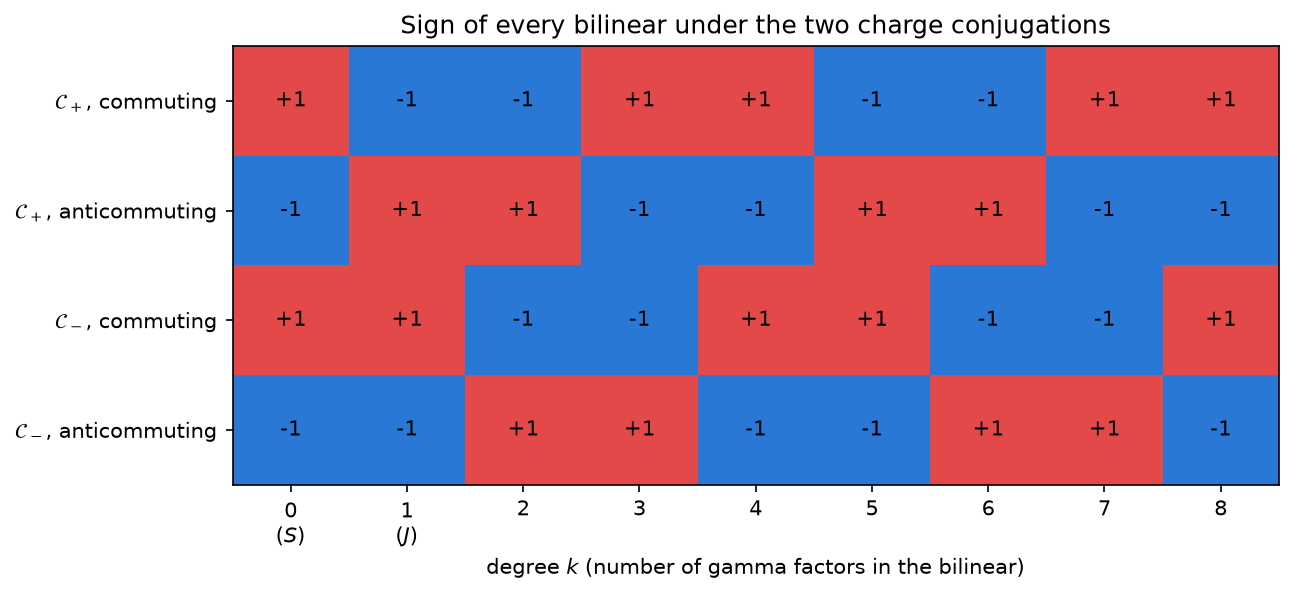

Figure 21a.6 saved as Revision/textbook/figures/21a_6_bilinear_signs.png


In [16]:
fig, ax = plt.subplots(figsize=(9.0, 3.8))
ax.imshow(degree_signs, cmap=SIGNS, vmin=-1, vmax=1, aspect="auto")
for row in range(4):
    for k in range(9):
        ax.text(k, row, f"{degree_signs[row, k]:+d}", ha="center", va="center")
ax.set_xticks(range(9), ["0\n($S$)", "1\n($J$)"] + [str(k) for k in range(2, 9)])
ax.set_yticks(range(4), [r"$\mathcal{C}_+$, commuting",
                         r"$\mathcal{C}_+$, anticommuting",
                         r"$\mathcal{C}_-$, commuting",
                         r"$\mathcal{C}_-$, anticommuting"])
ax.set_xlabel("degree $k$ (number of gamma factors in the bilinear)")
ax.set_title("Sign of every bilinear under the two charge conjugations")
ax.grid(False)
save_figure(fig, "bilinear_signs",
            "The sign that each of the 256 bilinears $\\bar\\Psi\\gamma^{a_1}"
            "\\cdots\\gamma^{a_k}\\Psi$ acquires under $\\Psi \\to M\\Psi^\\ast$ "
            "($M = 1$ for $\\mathcal{C}_+$, $M = \\Gamma$ for $\\mathcal{C}_-$), "
            "for commuting and anticommuting components; horizontal axis the degree "
            "$k$, rows the four cases, colour and number the sign (red $+1$, blue "
            "$-1$). All products of the same degree share one sign. For commuting "
            "components $\\mathcal{C}_+$ keeps the scalar $S$ ($k = 0$) and "
            "reverses the current $J$ ($k = 1$); anticommuting components reverse "
            "every sign.")

**A numerical confirmation with numbers.** For commuting components the bilinears
are ordinary complex numbers, and we can simply evaluate them. The next cell takes
a fixed complex field value $\Psi$ (from a random-number generator with the fixed
seed 2101, so every run gives the same numbers), computes $S$ and the eight $J^a$
for $\Psi$, $\Psi^*$ and $\Gamma\Psi^*$, and checks the signs of the table:
$\Psi^*$ keeps $S$ and reverses $J$; $\Gamma\Psi^*$ keeps both.

In [17]:
rng = np.random.default_rng(2101)  # a fixed seed: the same numbers in every run
psi = rng.normal(size=16) + 1j * rng.normal(size=16)  # a complex field value


def S_of(p):
    """S = Psi^dagger C Psi."""
    return np.conj(p) @ C @ p


def J_of(p):
    """The eight currents J^a = Psi^dagger (-i C gamma^a) Psi."""
    return np.array([np.conj(p) @ K @ p for K in K_J])


for label, p in (("Psi", psi), ("Psi*", np.conj(psi)),
                 ("Gamma Psi*", Gamma @ np.conj(psi))):
    say(f"{label:10}: S = {S_of(p).real:+.4f}, J^(x4) = {J_of(p)[3].real:+.4f}")
check(np.isclose(S_of(np.conj(psi)), S_of(psi))
      and np.allclose(J_of(np.conj(psi)), -J_of(psi))
      and np.isclose(S_of(Gamma @ np.conj(psi)), S_of(psi))
      and np.allclose(J_of(Gamma @ np.conj(psi)), J_of(psi)),
      "numbers: Psi* keeps S and reverses J; Gamma Psi* keeps S and J")

Psi       : S = +6.0205, J^(x4) = +6.4970
Psi*      : S = +6.0205, J^(x4) = -6.4970
Gamma Psi*: S = +6.0205, J^(x4) = +6.4970
PASS numbers: Psi* keeps S and reverses J; Gamma Psi* keeps S and J


## 12. Real fields

For a **real** field ($\Psi^* = \Psi$) with commuting components:

1. $\mathcal{C}_+$ maps $\Psi$ to $\Psi^c = \Psi^* = \Psi$: it is the identity. A
   real field is its own charge conjugate.
2. Every current vanishes: $J^a = -i\Psi^TC\gamma^a\Psi = 0$, because the matrix
   $C\gamma^a$ is antisymmetric, and $\Psi^TA\Psi = \sum_{r,c}\Psi_rA_{rc}\Psi_c$
   is zero for an antisymmetric $A$ (the terms $(r, c)$ and $(c, r)$ cancel). A
   real field carries no U(1) charge.
3. The real matrix $\Gamma$ maps real fields to real fields, keeps
   $S = \Psi^TC\Psi$ (since $\Gamma^TC\Gamma = C$) and reverses every kinetic
   matrix ($\Gamma^TC\gamma^a\Gamma = -C\gamma^a$). With $m \to -m$ and
   $\lambda \to -\lambda$ it maps solutions to solutions (theorem T1 of the
   Revision pairing record). For real fields, the matter-antimatter map is the
   **matrix** $\Gamma$ together with the reversed mass.

The next cell checks these statements exactly with sympy, using a real field with
16 symbolic real components $r_1, \dots, r_{16}$ (record check
real_fields_charge_conjugation).

In [18]:
r = sp.Matrix(sp.symbols("r1:17", real=True))  # a real field with symbolic entries
C_s = sp.Matrix(C.tolist())
antisymmetric = all(np.array_equal((C @ gamma[x]).T, -(C @ gamma[x])) for x in COORDS)
currents_zero = all(sp.expand((-sp.I * r.T * C_s * G[x] * r)[0, 0]) == 0
                    for x in COORDS)
S_kept = sp.expand((Gamma_s * r).T * C_s * (Gamma_s * r) - r.T * C_s * r) == \
    sp.zeros(1, 1)
kinetic_reversed = all(np.array_equal(Gamma.T @ C @ gamma[x] @ Gamma, -(C @ gamma[x]))
                       for x in COORDS)
check(antisymmetric and currents_zero and S_kept and kinetic_reversed
      and lead_passed("real_fields_charge_conjugation"),
      "real fields: J^a = 0, calC_+ is the identity, Gamma keeps S and reverses "
      "every kinetic matrix C gamma^a",
      record=f"{RECORD}, check real_fields_charge_conjugation")

PASS real fields: J^a = 0, calC_+ is the identity, Gamma keeps S and reverses every
    kinetic matrix C gamma^a
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    real_fields_charge_conjugation


The next cell draws two pictures of these facts. Left: the matrix
$C\gamma^{(x4)}$, which is antisymmetric (the entry in row $r$, column $c$ is minus
the entry in row $c$, column $r$: the picture is its own mirror image across the
diagonal with the colours exchanged). Right: for two fixed real columns $\Psi$ and
$\Phi$ (think of $\Phi$ as the derivative of $\Psi$ in the kinetic term), the eight
kinetic numbers $\Psi^TC\gamma^a\Phi$ before and after the map $\Gamma$: all eight
change sign, while the scalar $S = \Psi^TC\Psi$ is unchanged.

S before = -6.5629, S after = -6.5629
PASS numbers: Gamma reverses the eight kinetic numbers and keeps S


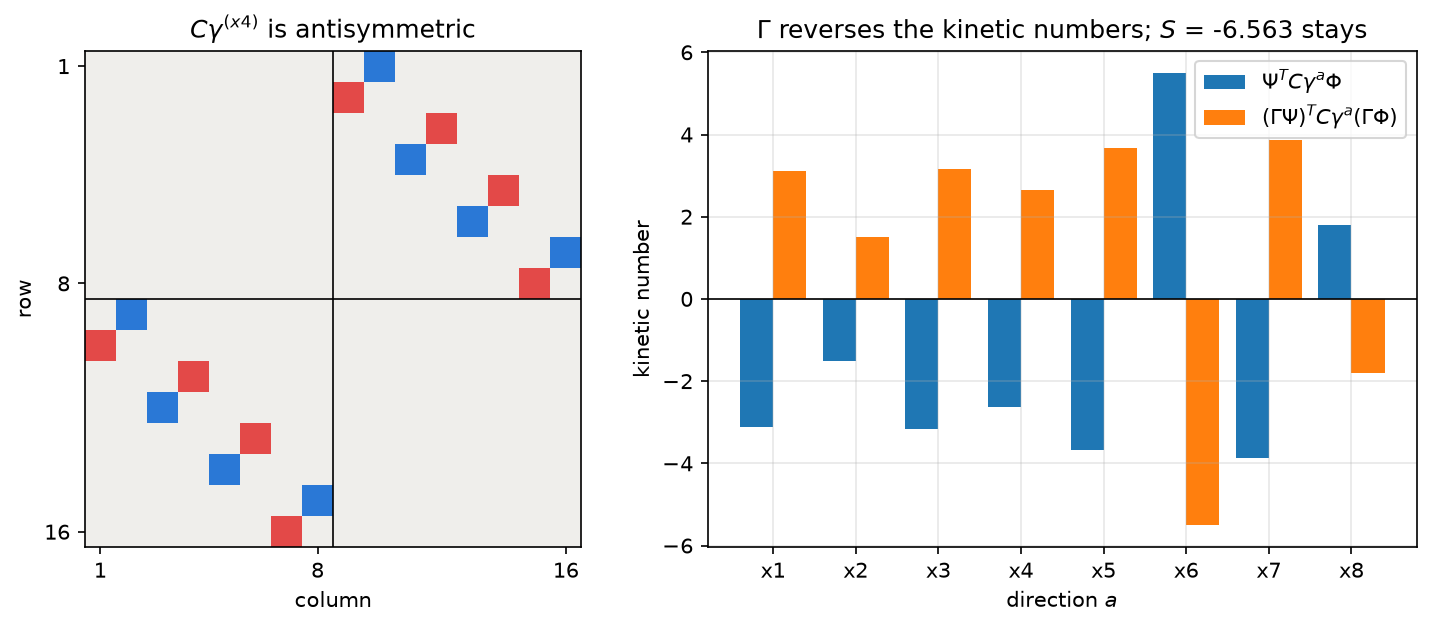

Figure 21a.7 saved as Revision/textbook/figures/21a_7_real_fields.png


In [19]:
psi_r = rng.normal(size=16)  # a real column
phi_r = rng.normal(size=16)  # a second real column
kinetic_before = np.array([psi_r @ C @ gamma[x] @ phi_r for x in COORDS])
kinetic_after = np.array([(Gamma @ psi_r) @ C @ gamma[x] @ (Gamma @ phi_r)
                          for x in COORDS])
S_before, S_after = psi_r @ C @ psi_r, (Gamma @ psi_r) @ C @ (Gamma @ psi_r)
say(f"S before = {S_before:+.4f}, S after = {S_after:+.4f}")
check(np.allclose(kinetic_after, -kinetic_before) and np.isclose(S_after, S_before),
      "numbers: Gamma reverses the eight kinetic numbers and keeps S")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), width_ratios=[1, 1.4])
heat_map(axes[0], C @ gamma["x4"], r"$C\gamma^{(x4)}$ is antisymmetric")
positions = np.arange(8)
axes[1].bar(positions - 0.2, kinetic_before, width=0.4,
            label=r"$\Psi^T C\gamma^a\Phi$")
axes[1].bar(positions + 0.2, kinetic_after, width=0.4,
            label=r"$(\Gamma\Psi)^T C\gamma^a(\Gamma\Phi)$")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xticks(positions, COORDS)
axes[1].set_xlabel("direction $a$")
axes[1].set_ylabel("kinetic number")
axes[1].set_title(f"$\\Gamma$ reverses the kinetic numbers; $S$ = {S_before:.3f} "
                  "stays")
axes[1].legend()
save_figure(fig, "real_fields",
            "Real fields. Left: heat map of the real matrix $C\\gamma^{(x4)}$ "
            "(horizontal axis the column, vertical axis the row, red $+1$, blue "
            "$-1$); it is antisymmetric, so $\\Psi^T C\\gamma^{(x4)}\\Psi = 0$ for "
            "every real $\\Psi$ and a real field carries no current. Right: the "
            "eight kinetic numbers $\\Psi^T C\\gamma^a\\Phi$ of two fixed real "
            "columns (left bars) and of their images under the real matrix "
            "$\\Gamma$ (right bars); horizontal axis the direction $a$, vertical "
            "axis the value (pure numbers). Every kinetic number changes sign "
            "while $S = \\Psi^T C\\Psi$ stays: with the mass reversed, $\\Gamma$ "
            "maps real solutions to real solutions.")

## 13. The Revision record and the figure files

The next cell checks that the Revision record of the lead checks reports all its
checks as passed, and that the nine checks reproduced in this notebook are among
them. (The remaining three are reproduced elsewhere in this chapter's notebooks:
the reality of the spin connection and the U(1) identity concern charge
conservation, and the last check concerns the quantised field.) Then it checks
that the seven figure files exist and prints the number of checks that passed.

In [20]:
REPRODUCED_HERE = ["representation_real", "B_imaginary_hermitian",
                   "intertwiners_same_mass", "intertwiners_reversed_mass",
                   "charge_conjugation_matrix_plus", "charge_conjugation_matrix_minus",
                   "majorana_conditions_consistent",
                   "bilinears_under_charge_conjugation",
                   "real_fields_charge_conjugation"]
summary = lead["summary"]
check(summary["passed"] == summary["total"] == 12
      and all(lead_passed(name) for name in REPRODUCED_HERE),
      "the lead record passes 12 of 12; the nine checks reproduced here are in it")
names = sorted(FIGURE_NUMBERS, key=FIGURE_NUMBERS.get)  # in the order of saving
check(len(names) == 7 and all(
    output_file(f"{FIGURE_FOLDER}/21a_{FIGURE_NUMBERS[n]}_{n}.png").is_file()
    for n in names), "the seven figure files of notebook 21a exist")
all_checks_passed()

PASS the lead record passes 12 of 12; the nine checks reproduced here are in it
PASS the seven figure files of notebook 21a exist
ALL 26 CHECKS PASSED (notebook 21a)


## 14. What this notebook showed

- PROVED (exact, whole-number arithmetic): the calculation uses **eight real
  $16 \times 16$ gamma matrices** (signed permutation matrices) that obey the
  Clifford relation of signature (4,4), $\eta = \mathrm{diag}(+1, +1, +1, -1, -1,
  -1, -1, +1)$ in the order $x1, \dots, x8$.
- PROVED (exact rational linear algebra): the only matrices $M$ with
  $M(\gamma^a)^* = s\,\gamma^a M$ for all eight gammas are the multiples of $1$
  ($s = +1$, same mass) and of $\Gamma$ ($s = -1$, mass reversed); each gamma
  equation halves the solution space, $256 \to 128 \to \dots \to 1$.
- PROVED: the two charge-conjugation matrices are $\mathcal{C}_+ = C$ (with
  $\mathcal{C}_+^{-1}\gamma^a\mathcal{C}_+ = -(\gamma^a)^T$; $\Psi^c = \Psi^*$) and
  $\mathcal{C}_- = \Gamma C$ (with $\mathcal{C}_-^{-1}\gamma^a\mathcal{C}_- =
  +(\gamma^a)^T$; $\Psi^c = \Gamma\Psi^*$); both are real, and both reality
  (Majorana) conditions are consistent.
- PROVED (exact, sympy): on the Revision record's exact solution in the author's
  curved metric (valid for every history $a_4$, the deflating one included),
  $\Psi^*$ solves the equation with the same mass and $\Gamma\Psi^*$ the one with
  the reversed mass.
- PROVED: under $\mathcal{C}_+$ commuting components keep $S$ and reverse $J$;
  under $\mathcal{C}_-$ they keep both; anticommuting components reverse every
  sign classically; all 256 bilinears follow the degree rules $(-1)^{k(k+1)/2}$
  and $(-1)^{k(k-1)/2}$.
- PROVED: for a real field $\mathcal{C}_+$ is the identity and $J = 0$ (a real
  field is its own conjugate and has no U(1) charge); the nontrivial real map is
  the matrix $\Gamma$ with the mass reversed. Plain complex conjugation is never
  the charge conjugation of a real field: charge conjugation is a matrix.
- Reproduced: nine checks of `Revision/lead_checks/reports/
  charge-conjugation-and-u1.json` and the check exact_solution_family_x4_x8 of
  `Revision/theory/reports/python-field-theory.json`.